In [1]:
"""
8x8 Jigsaw Puzzle Solver
========================
Strategies adapted from 4x4 solver, scaled for 64 pieces:
1. Beam Search with Best Buddies
2. Multi-Width Edge Matching
3. Block Merging
4. Greedy Row/Column Building
5. Simulated Annealing
6. Random Restarts with Refinement
"""

import cv2
import numpy as np
import os
import random
import math
from collections import defaultdict

# ============ CONFIGURATION ============
GRID_SIZE = 8
NUM_PIECES = 64

BASE = "./results"
GT_DIR = "../data/correct"
COLOR_DIR = os.path.join(BASE, "enhanced_images_sliced", "puzzle_8x8")
OUTPUT_DIR = os.path.join(BASE, "8x8_out")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============ UTILITY FUNCTIONS ============
def sort_key(f):
    name = f.replace('piece_', '').split('.')[0]
    return int(name) if name.isdigit() else name

def load_pieces(folder):
    """Load all 64 pieces from a folder."""
    if not os.path.exists(folder):
        return None
    files = sorted([f for f in os.listdir(folder) if f.endswith(('.png', '.jpg'))], key=sort_key)
    pieces = [cv2.imread(os.path.join(folder, f)) for f in files]
    pieces = [p for p in pieces if p is not None]
    return pieces if len(pieces) == NUM_PIECES else None

def get_edge(img, side, w=1):
    """Extract edge pixels from an image."""
    if side == 'top': return img[:w, :, :]
    if side == 'bottom': return img[-w:, :, :]
    if side == 'left': return img[:, :w, :]
    if side == 'right': return img[:, -w:, :]

def lab_ssd(p1, p2, s1, s2, width=1):
    """Compute LAB color space SSD between two edges."""
    e1 = cv2.cvtColor(get_edge(p1, s1, width), cv2.COLOR_BGR2LAB).astype(np.float32)
    e2 = cv2.cvtColor(get_edge(p2, s2, width), cv2.COLOR_BGR2LAB).astype(np.float32)
    if s1 in ('left', 'right'): e1 = np.transpose(e1, (1, 0, 2))
    if s2 in ('left', 'right'): e2 = np.transpose(e2, (1, 0, 2))
    if e1.shape != e2.shape: return 1e9
    return np.sum((e1 - e2) ** 2) / e1.size

def gradient_compatibility(p1, p2, s1, s2, width=2):
    """Compute gradient-based compatibility."""
    e1 = get_edge(p1, s1, width)
    e2 = get_edge(p2, s2, width)
    
    g1 = cv2.cvtColor(e1, cv2.COLOR_BGR2GRAY).astype(np.float32)
    g2 = cv2.cvtColor(e2, cv2.COLOR_BGR2GRAY).astype(np.float32)
    
    if s1 in ('left', 'right'): g1 = g1.T
    if s2 in ('left', 'right'): g2 = g2.T
    
    # Compute gradients
    gx1 = cv2.Sobel(g1, cv2.CV_32F, 1, 0, ksize=3)
    gx2 = cv2.Sobel(g2, cv2.CV_32F, 1, 0, ksize=3)
    
    if g1.shape != g2.shape:
        return 1e9
    
    return np.mean(np.abs(gx1 - gx2))

# ============ MAIN SOLVER CLASS ============
class Solver8x8:
    def __init__(self, pieces):
        self.pieces = pieces
        self.n = len(pieces)
        
        print("Building compatibility matrices...")
        
        # Standard compatibility matrices (width=1)
        self.rc = np.full((self.n, self.n), np.inf)  # right-left compatibility
        self.bc = np.full((self.n, self.n), np.inf)  # bottom-top compatibility
        
        # Multi-width matrices (width=2)
        self.rc2 = np.full((self.n, self.n), np.inf)
        self.bc2 = np.full((self.n, self.n), np.inf)
        
        for i in range(self.n):
            for j in range(self.n):
                if i != j:
                    self.rc[i, j] = lab_ssd(pieces[i], pieces[j], 'right', 'left', 1)
                    self.bc[i, j] = lab_ssd(pieces[i], pieces[j], 'bottom', 'top', 1)
                    self.rc2[i, j] = lab_ssd(pieces[i], pieces[j], 'right', 'left', 2)
                    self.bc2[i, j] = lab_ssd(pieces[i], pieces[j], 'bottom', 'top', 2)
        
        # Combined multi-width compatibility
        self.rcm = 0.6 * self.rc + 0.4 * self.rc2
        self.bcm = 0.6 * self.bc + 0.4 * self.bc2
        
        # Find best buddies (mutual best matches)
        self.hb, self.vb = {}, {}
        for a in range(self.n):
            b = np.argmin(self.rc[a, :])
            if np.argmin(self.rc[:, b]) == a:
                self.hb[a] = b
        for a in range(self.n):
            b = np.argmin(self.bc[a, :])
            if np.argmin(self.bc[:, b]) == a:
                self.vb[a] = b
        
        print(f"Found {len(self.hb)} horizontal buddies, {len(self.vb)} vertical buddies")
    
    def evaluate(self, solution):
        """Evaluate solution quality (lower is better)."""
        grid = np.array(solution).reshape((GRID_SIZE, GRID_SIZE))
        total = 0
        bb_count = 0
        loop_count = 0
        
        # Horizontal edges
        for r in range(GRID_SIZE):
            for c in range(GRID_SIZE - 1):
                i, j = grid[r, c], grid[r, c + 1]
                total += self.rc[i, j]
                if self.hb.get(i) == j:
                    bb_count += 1
        
        # Vertical edges
        for r in range(GRID_SIZE - 1):
            for c in range(GRID_SIZE):
                i, j = grid[r, c], grid[r + 1, c]
                total += self.bc[i, j]
                if self.vb.get(i) == j:
                    bb_count += 1
        
        # 2x2 loop consistency check
        for r in range(GRID_SIZE - 1):
            for c in range(GRID_SIZE - 1):
                tl, tr = grid[r, c], grid[r, c + 1]
                bl, br = grid[r + 1, c], grid[r + 1, c + 1]
                loop = self.rc[tl, tr] + self.bc[tr, br] + self.rc[bl, br] + self.bc[tl, bl]
                if loop < 4000:
                    loop_count += 1
        
        return total - bb_count * 5000 - loop_count * 1500
    
    def refine(self, sol, iterations=500):
        """Local refinement by swapping pieces."""
        current = list(sol)
        best_c = self.evaluate(current)
        
        for _ in range(iterations):
            improved = False
            for i in range(NUM_PIECES):
                for j in range(i + 1, NUM_PIECES):
                    new = current[:]
                    new[i], new[j] = new[j], new[i]
                    nc = self.evaluate(new)
                    if nc < best_c:
                        best_c, current = nc, new
                        improved = True
                        break
                if improved:
                    break
            if not improved:
                break
        return current
    
    def simulated_annealing(self, sol, iterations=3000):
        """Simulated annealing optimization."""
        current = list(sol)
        current_cost = self.evaluate(current)
        best, best_cost = current[:], current_cost
        temp = 3000.0
        
        for _ in range(iterations):
            # Random swap
            i1, i2 = random.sample(range(NUM_PIECES), 2)
            new = current[:]
            new[i1], new[i2] = new[i2], new[i1]
            new_cost = self.evaluate(new)
            
            delta = new_cost - current_cost
            if delta < 0 or random.random() < math.exp(-delta / max(temp, 1)):
                current, current_cost = new, new_cost
                if current_cost < best_cost:
                    best, best_cost = current[:], current_cost
            
            temp *= 0.998
        
        return best
    
    # ============ STRATEGY 1: BEAM SEARCH ============
    def strategy_beam(self, use_multi=False, beam_width=200):
        """Beam search building grid row by row."""
        rc = self.rcm if use_multi else self.rc
        bc = self.bcm if use_multi else self.bc
        bb_mult = 0.05 if use_multi else 0.1
        
        best_sol, best_cost = None, float('inf')
        
        # Try different starting pieces
        starts = list(range(min(16, NUM_PIECES)))  # Try first 16 pieces as starts
        
        for start in starts:
            beam = [(0.0, [start], {start})]
            
            for pos in range(1, NUM_PIECES):
                row, col = pos // GRID_SIZE, pos % GRID_SIZE
                cands = []
                
                for cost, pl, used in beam:
                    for p in range(NUM_PIECES):
                        if p in used:
                            continue
                        add = 0
                        
                        # Left neighbor compatibility
                        if col > 0:
                            left = pl[pos - 1]
                            add += rc[left, p]
                            if self.hb.get(left) == p:
                                add *= bb_mult
                        
                        # Top neighbor compatibility
                        if row > 0:
                            top = pl[pos - GRID_SIZE]
                            add += bc[top, p]
                            if self.vb.get(top) == p:
                                add *= bb_mult
                        
                        cands.append((cost + add, pl + [p], used | {p}))
                
                cands.sort(key=lambda x: x[0])
                beam = cands[:beam_width]
            
            if beam and beam[0][0] < best_cost:
                best_cost = beam[0][0]
                best_sol = beam[0][1]
        
        return best_sol
    
    # ============ STRATEGY 2: GREEDY ROW BUILDING ============
    def strategy_greedy_rows(self):
        """Build rows greedily, then arrange rows."""
        best_sol, best_cost = None, float('inf')
        
        # Try building from different starting pieces
        for start in range(min(16, NUM_PIECES)):
            used = set()
            rows = []
            
            # Build 8 rows
            for row_idx in range(GRID_SIZE):
                row = []
                
                if row_idx == 0:
                    # First row: start with given piece
                    row.append(start)
                    used.add(start)
                else:
                    # Other rows: find best piece below first piece of previous row
                    prev_first = rows[row_idx - 1][0]
                    best_p, best_s = -1, float('inf')
                    for p in range(NUM_PIECES):
                        if p in used:
                            continue
                        s = self.bc[prev_first, p]
                        if self.vb.get(prev_first) == p:
                            s *= 0.1
                        if s < best_s:
                            best_s, best_p = s, p
                    if best_p >= 0:
                        row.append(best_p)
                        used.add(best_p)
                
                # Fill rest of row
                while len(row) < GRID_SIZE:
                    left = row[-1]
                    best_p, best_s = -1, float('inf')
                    
                    for p in range(NUM_PIECES):
                        if p in used:
                            continue
                        s = self.rc[left, p]
                        if self.hb.get(left) == p:
                            s *= 0.1
                        # Also consider top alignment if not first row
                        if row_idx > 0:
                            top = rows[row_idx - 1][len(row)]
                            s += self.bc[top, p]
                            if self.vb.get(top) == p:
                                s *= 0.5
                        if s < best_s:
                            best_s, best_p = s, p
                    
                    if best_p >= 0:
                        row.append(best_p)
                        used.add(best_p)
                    else:
                        break
                
                rows.append(row)
            
            # Flatten to solution
            if all(len(r) == GRID_SIZE for r in rows) and len(rows) == GRID_SIZE:
                sol = [p for row in rows for p in row]
                cost = self.evaluate(sol)
                if cost < best_cost:
                    best_cost, best_sol = cost, sol
        
        return best_sol
    
    # ============ STRATEGY 3: BLOCK MERGING ============
    def strategy_blocks(self):
        """Hierarchical block merging."""
        class Block:
            def __init__(self, idx, img):
                self.idx = np.array([[idx]])
                self.img = img
        
        blocks = [Block(i, p) for i, p in enumerate(self.pieces)]
        
        def block_cost(b1, b2, side):
            lab1 = cv2.cvtColor(b1.img, cv2.COLOR_BGR2LAB).astype(np.float32)
            lab2 = cv2.cvtColor(b2.img, cv2.COLOR_BGR2LAB).astype(np.float32)
            if side == 'r':
                e1, e2 = lab1[:, -1, :], lab2[:, 0, :]
            else:
                e1, e2 = lab1[-1, :, :], lab2[0, :, :]
            return np.sum((e1 - e2) ** 2) / e1.size
        
        max_iterations = 1000
        for iteration in range(max_iterations):
            if len(blocks) <= 1:
                break
            
            best_merge, best_score = None, float('inf')
            
            for i in range(len(blocks)):
                for j in range(len(blocks)):
                    if i == j:
                        continue
                    b1, b2 = blocks[i], blocks[j]
                    
                    # Horizontal merge (b1 left of b2)
                    if (b1.idx.shape[1] + b2.idx.shape[1] <= GRID_SIZE and 
                        b1.idx.shape[0] == b2.idx.shape[0]):
                        s = block_cost(b1, b2, 'r')
                        if s < best_score:
                            best_score, best_merge = s, (i, j, 'r')
                    
                    # Vertical merge (b1 above b2)
                    if (b1.idx.shape[0] + b2.idx.shape[0] <= GRID_SIZE and 
                        b1.idx.shape[1] == b2.idx.shape[1]):
                        s = block_cost(b1, b2, 'b')
                        if s < best_score:
                            best_score, best_merge = s, (i, j, 'b')
            
            if best_merge is None:
                break
            
            i, j, side = best_merge
            b1, b2 = blocks[i], blocks[j]
            
            if side == 'r':
                new_idx = np.hstack([b1.idx, b2.idx])
                new_img = np.hstack([b1.img, b2.img])
            else:
                new_idx = np.vstack([b1.idx, b2.idx])
                new_img = np.vstack([b1.img, b2.img])
            
            new_block = Block(-1, new_img)
            new_block.idx = new_idx
            
            for x in sorted([i, j], reverse=True):
                blocks.pop(x)
            blocks.append(new_block)
        
        if len(blocks) == 1 and blocks[0].idx.shape == (GRID_SIZE, GRID_SIZE):
            return blocks[0].idx.flatten().tolist()
        return None
    
    # ============ STRATEGY 4: RANDOM RESTART ============
    def strategy_random_restart(self, n_restarts=15):
        """Multiple random starts with SA optimization."""
        best_sol, best_cost = None, float('inf')
        
        for _ in range(n_restarts):
            # Random permutation
            perm = list(range(NUM_PIECES))
            random.shuffle(perm)
            
            # SA to improve
            refined = self.simulated_annealing(perm, 1000)
            cost = self.evaluate(refined)
            
            if cost < best_cost:
                best_cost = cost
                best_sol = refined
        
        return best_sol
    
    # ============ STRATEGY 5: BUDDY CHAIN ============
    def strategy_buddy_chain(self):
        """Build chains from best buddy pairs."""
        best_sol, best_cost = None, float('inf')
        
        # Try starting from pieces with horizontal buddies
        for start in list(self.hb.keys())[:12]:
            grid = [[-1] * GRID_SIZE for _ in range(GRID_SIZE)]
            grid[0][0] = start
            
            # Fill first row using horizontal buddies
            for c in range(1, GRID_SIZE):
                prev = grid[0][c - 1]
                if prev in self.hb and self.hb[prev] not in [x for row in grid for x in row if x >= 0]:
                    grid[0][c] = self.hb[prev]
                else:
                    # Find best match
                    used = {x for row in grid for x in row if x >= 0}
                    best_p, best_s = -1, float('inf')
                    for p in range(NUM_PIECES):
                        if p in used:
                            continue
                        s = self.rc[prev, p]
                        if s < best_s:
                            best_s, best_p = s, p
                    grid[0][c] = best_p
            
            # Fill remaining rows
            for r in range(1, GRID_SIZE):
                for c in range(GRID_SIZE):
                    used = {x for row in grid for x in row if x >= 0}
                    top = grid[r - 1][c]
                    left = grid[r][c - 1] if c > 0 else -1
                    
                    best_p, best_s = -1, float('inf')
                    for p in range(NUM_PIECES):
                        if p in used:
                            continue
                        s = self.bc[top, p]
                        if self.vb.get(top) == p:
                            s *= 0.1
                        if left >= 0:
                            s += self.rc[left, p]
                            if self.hb.get(left) == p:
                                s *= 0.5
                        if s < best_s:
                            best_s, best_p = s, p
                    
                    grid[r][c] = best_p
            
            sol = [grid[r][c] for r in range(GRID_SIZE) for c in range(GRID_SIZE)]
            if -1 not in sol and len(set(sol)) == NUM_PIECES:
                cost = self.evaluate(sol)
                if cost < best_cost:
                    best_cost, best_sol = cost, sol
        
        return best_sol
    
    # ============ STRATEGY 6: COLUMN FIRST ============
    def strategy_column_first(self):
        """Build columns first, then arrange."""
        best_sol, best_cost = None, float('inf')
        
        for start in range(min(16, NUM_PIECES)):
            used = set()
            cols = []
            
            # Build 8 columns
            for col_idx in range(GRID_SIZE):
                col = []
                
                if col_idx == 0:
                    col.append(start)
                    used.add(start)
                else:
                    # Find best piece to the right of first piece of previous column
                    prev_first = cols[col_idx - 1][0]
                    best_p, best_s = -1, float('inf')
                    for p in range(NUM_PIECES):
                        if p in used:
                            continue
                        s = self.rc[prev_first, p]
                        if self.hb.get(prev_first) == p:
                            s *= 0.1
                        if s < best_s:
                            best_s, best_p = s, p
                    if best_p >= 0:
                        col.append(best_p)
                        used.add(best_p)
                
                # Fill rest of column
                while len(col) < GRID_SIZE:
                    top = col[-1]
                    best_p, best_s = -1, float('inf')
                    
                    for p in range(NUM_PIECES):
                        if p in used:
                            continue
                        s = self.bc[top, p]
                        if self.vb.get(top) == p:
                            s *= 0.1
                        # Also consider left alignment
                        if col_idx > 0:
                            left = cols[col_idx - 1][len(col)]
                            s += self.rc[left, p]
                            if self.hb.get(left) == p:
                                s *= 0.5
                        if s < best_s:
                            best_s, best_p = s, p
                    
                    if best_p >= 0:
                        col.append(best_p)
                        used.add(best_p)
                    else:
                        break
                
                cols.append(col)
            
            # Convert columns to row-major solution
            if all(len(c) == GRID_SIZE for c in cols) and len(cols) == GRID_SIZE:
                sol = []
                for r in range(GRID_SIZE):
                    for c in range(GRID_SIZE):
                        sol.append(cols[c][r])
                cost = self.evaluate(sol)
                if cost < best_cost:
                    best_cost, best_sol = cost, sol
        
        return best_sol
    
    def solve(self):
        """Run all strategies and return best solution."""
        candidates = []
        
        print("Running Strategy 1a: Standard Beam Search...")
        sol = self.strategy_beam(use_multi=False, beam_width=150)
        if sol and len(sol) == NUM_PIECES:
            candidates.append(("beam_std", sol))
        
        print("Running Strategy 1b: Multi-width Beam Search...")
        sol = self.strategy_beam(use_multi=True, beam_width=150)
        if sol and len(sol) == NUM_PIECES:
            candidates.append(("beam_multi", sol))
        
        print("Running Strategy 2: Greedy Rows...")
        sol = self.strategy_greedy_rows()
        if sol and len(sol) == NUM_PIECES:
            candidates.append(("greedy_rows", sol))
        
        print("Running Strategy 3: Block Merging...")
        sol = self.strategy_blocks()
        if sol and len(sol) == NUM_PIECES:
            candidates.append(("blocks", sol))
        
        print("Running Strategy 4: Random Restart...")
        sol = self.strategy_random_restart(n_restarts=10)
        if sol and len(sol) == NUM_PIECES:
            candidates.append(("random_restart", sol))
        
        print("Running Strategy 5: Buddy Chain...")
        sol = self.strategy_buddy_chain()
        if sol and len(sol) == NUM_PIECES:
            candidates.append(("buddy_chain", sol))
        
        print("Running Strategy 6: Column First...")
        sol = self.strategy_column_first()
        if sol and len(sol) == NUM_PIECES:
            candidates.append(("column_first", sol))
        
        if not candidates:
            print("No valid solution found, returning identity.")
            return list(range(NUM_PIECES))
        
        print(f"\nRefining {len(candidates)} candidates...")
        
        # Refine all candidates
        refined = []
        for name, c in candidates:
            # Deep refine
            r1 = self.refine(c, iterations=300)
            # SA
            r2 = self.simulated_annealing(r1, iterations=2000)
            # Final refine
            r3 = self.refine(r2, iterations=200)
            cost = self.evaluate(r3)
            refined.append((name, r3, cost))
        
        # Pick best
        refined.sort(key=lambda x: x[2])
        print(f"Best strategy: {refined[0][0]} with cost {refined[0][2]:.2f}")
        return refined[0][1]

# ============ ASSEMBLY AND EVALUATION ============
def solve(pieces):
    """Main solve function."""
    return Solver8x8(pieces).solve()

def assemble(pieces, order):
    """Assemble pieces into final image."""
    h, w = pieces[0].shape[:2]
    result = np.zeros((GRID_SIZE * h, GRID_SIZE * w, 3), dtype=np.uint8)
    
    for pos, idx in enumerate(order):
        r, c = pos // GRID_SIZE, pos % GRID_SIZE
        result[r * h:(r + 1) * h, c * w:(c + 1) * w] = pieces[idx]
    
    return result

def mse(a, b):
    """Mean squared error between two images."""
    if a.shape != b.shape:
        b = cv2.resize(b, (a.shape[1], a.shape[0]))
    return np.mean((a.astype(float) - b.astype(float)) ** 2)

def evaluate(limit=110):
    """Evaluate solver on dataset."""
    folders = sorted(
        [f for f in os.listdir(COLOR_DIR) if os.path.isdir(os.path.join(COLOR_DIR, f))],
        key=lambda x: int(x) if x.isdigit() else x
    )
    
    correct, total = 0, 0
    results = []
    
    print("=" * 70)
    print(f"{'Puzzle':<8} | {'MSE':<14} | {'Status':<8} | {'Strategy'}")
    print("=" * 70)
    
    for folder in folders[:limit]:
        pieces = load_pieces(os.path.join(COLOR_DIR, folder))
        if pieces is None:
            continue
        
        print(f"\n>>> Processing puzzle {folder}...")
        
        try:
            order = solve(pieces)
            result = assemble(pieces, order)
            
            # Save assembled image
            out_path = os.path.join(OUTPUT_DIR, f"{folder}_assembled.png")
            cv2.imwrite(out_path, result)
            
            # Load ground truth
            gt_path = os.path.join(GT_DIR, f"{folder}.png")
            if not os.path.exists(gt_path):
                gt_path = os.path.join(GT_DIR, f"{folder}.jpg")
            
            gt = cv2.imread(gt_path)
            error = mse(result, gt)
            status = "PASS" if error < 1500 else "FAIL"
            
            if status == "PASS":
                correct += 1
            
            results.append((folder, error, status))
            print(f"{folder:<8} | {error:<14.2f} | {status}")
            
        except Exception as e:
            print(f"{folder:<8} | ERROR: {str(e)}")
            results.append((folder, -1, "ERR"))
        
        total += 1
    
    print("\n" + "=" * 70)
    print(f"FINAL ACCURACY: {correct}/{total} ({100 * correct / total:.2f}%)")
    print("=" * 70)
    
    return results

In [3]:
# Run evaluation on all puzzles
results = evaluate(110)

Puzzle   | MSE            | Status   | Strategy

>>> Processing puzzle 0...
Building compatibility matrices...
Found 39 horizontal buddies, 43 vertical buddies
Running Strategy 1a: Standard Beam Search...
Running Strategy 1b: Multi-width Beam Search...
Running Strategy 2: Greedy Rows...
Running Strategy 3: Block Merging...
Running Strategy 4: Random Restart...
Running Strategy 5: Buddy Chain...
Running Strategy 6: Column First...

Refining 6 candidates...
Best strategy: beam_std with cost -163286.22
0        | 7754.15        | FAIL

>>> Processing puzzle 1...
Building compatibility matrices...
Found 43 horizontal buddies, 54 vertical buddies
Running Strategy 1a: Standard Beam Search...
Running Strategy 1b: Multi-width Beam Search...
Running Strategy 2: Greedy Rows...
Running Strategy 3: Block Merging...
Running Strategy 4: Random Restart...
Running Strategy 5: Buddy Chain...
Running Strategy 6: Column First...

Refining 6 candidates...
Best strategy: greedy_rows with cost -510325.17
1 

Loaded 64 pieces
Piece size: (28, 28, 3)
Building compatibility matrices...
Found 39 horizontal buddies, 43 vertical buddies
Running Strategy 1a: Standard Beam Search...
Running Strategy 1b: Multi-width Beam Search...
Running Strategy 2: Greedy Rows...
Running Strategy 3: Block Merging...
Running Strategy 4: Random Restart...
Running Strategy 5: Buddy Chain...
Running Strategy 6: Column First...

Refining 6 candidates...
Best strategy: beam_std with cost -163286.22


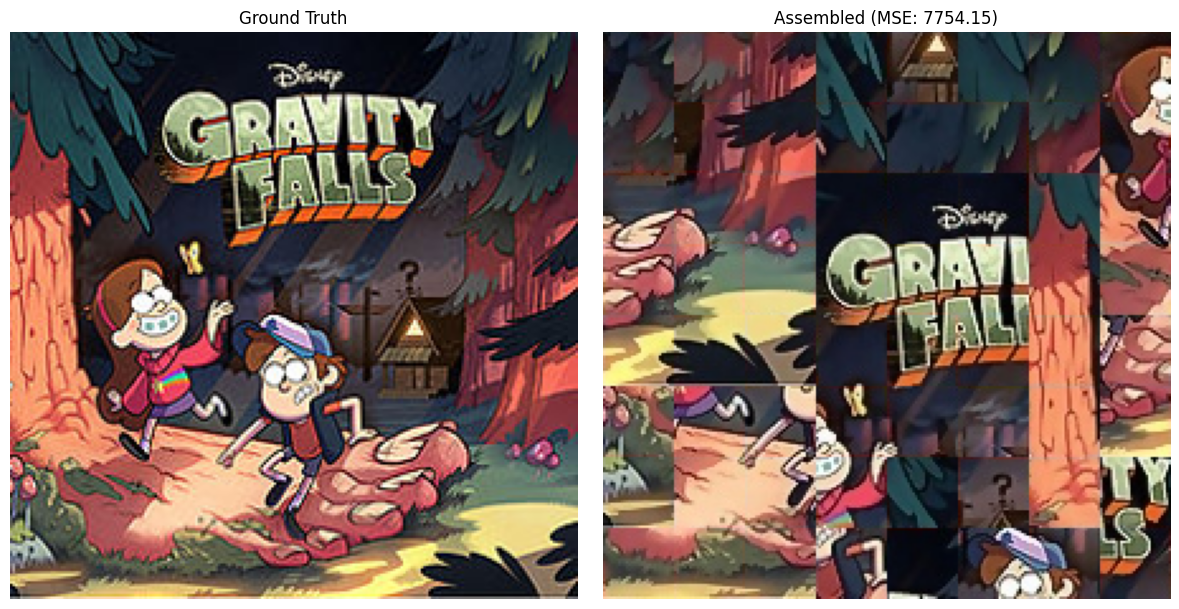

In [2]:
# Quick test on a single puzzle
import matplotlib.pyplot as plt

test_folder = "0"
pieces = load_pieces(os.path.join(COLOR_DIR, test_folder))

if pieces:
    print(f"Loaded {len(pieces)} pieces")
    print(f"Piece size: {pieces[0].shape}")
    
    # Solve
    order = solve(pieces)
    result = assemble(pieces, order)
    
    # Display
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    gt = cv2.imread(os.path.join(GT_DIR, f"{test_folder}.png"))
    if gt is None:
        gt = cv2.imread(os.path.join(GT_DIR, f"{test_folder}.jpg"))
    plt.imshow(cv2.cvtColor(gt, cv2.COLOR_BGR2RGB))
    plt.title("Ground Truth")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title(f"Assembled (MSE: {mse(result, gt):.2f})")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Failed to load pieces")

In [4]:
# Summary statistics
import pandas as pd

if 'results' in dir() and results:
    df = pd.DataFrame(results, columns=['Puzzle', 'MSE', 'Status'])
    
    print("\nResults Summary:")
    print(f"Total puzzles: {len(df)}")
    print(f"Passed: {len(df[df['Status'] == 'PASS'])}")
    print(f"Failed: {len(df[df['Status'] == 'FAIL'])}")
    print(f"Errors: {len(df[df['Status'] == 'ERR'])}")
    
    valid = df[df['MSE'] > 0]
    print(f"\nMSE Statistics (valid only):")
    print(f"  Mean: {valid['MSE'].mean():.2f}")
    print(f"  Median: {valid['MSE'].median():.2f}")
    print(f"  Min: {valid['MSE'].min():.2f}")
    print(f"  Max: {valid['MSE'].max():.2f}")


Results Summary:
Total puzzles: 110
Passed: 14
Failed: 96
Errors: 0

MSE Statistics (valid only):
  Mean: 5937.18
  Median: 5951.78
  Min: 22.79
  Max: 20244.97
